# Load necessary packages

In [1]:
suppressPackageStartupMessages({
library(svglite)
library(tidyverse)
library(scattermore)
    })

# Volcano plot function

In [2]:
volcano_plot = function(data, padj_threshold = 0.05, log2fc_threshold = 1.0, top_n = 10,
                        colors = NULL, plot_width = 1, inside_legend = FALSE, ymax = 8, xlims = c(-4,4)) {

    # Make sure data is the proper format. 
    data = as.data.frame(data)

    # Create empty plot in the event that there are no significant hits. 
    if (nrow(data) < 1) {
        p = ggplot() + theme_void() +
            labs(title = "Error", subtitle = "No data available (Treatment/Control)") +
            theme(plot.title = element_text(hjust = 0.5, face = "bold"), plot.subtitle = element_text(hjust = 0.5))
        return(p)
    }
    
    # Compute transformed p-values and add new significance column. 
    data$neg_log10_padj = -log10(pmax(data$padj, 0))
    data$significance = "Not Significant"
    data$significance[data$padj < padj_threshold & data$log2FoldChange > log2fc_threshold] = "Up"
    data$significance[data$padj < padj_threshold & data$log2FoldChange < -1*log2fc_threshold] = "Down"
    data$significance[data$padj < padj_threshold & abs(data$log2FoldChange) <= log2fc_threshold] = "Pass p-value cutoff"
    
    # Top genes for labeling. 
    top_genes = data[data$significance != "Not Significant", ]
    top_genes = top_genes[order(top_genes$padj), ]
    top_genes = head(top_genes, top_n)
    top_genes$label = top_genes$gene_name
    
    # Symmetric x-limit.
    max_l2fc = max(abs(data$log2FoldChange), na.rm = TRUE)
    
    # Build plot.
    p = ggplot(data, aes(x = log2FoldChange, y = neg_log10_padj, color = significance)) +
        geom_scattermore(alpha = 0.5, pointsize = 18.2, pixels = c(2056, 2056)) +
        scale_color_manual(values = c("Not Significant" = "gray70", "Up" = "red",
                                    "Down" = "blue", "Pass p-value cutoff" = "black"),
                         name = "Significance (Treatment/Control)" ) +
        geom_vline(xintercept = c(-1*log2fc_threshold, log2fc_threshold), linetype = "dashed", color = "black", linewidth = 0.5) +
        geom_hline(yintercept = -log10(padj_threshold), linetype = "dashed", color = "black", linewidth = 0.5) +
        labs(x = expression("Log"[2]*" fold change"), y = expression("-Log"[10]*"(adjusted p-value)")) +
        coord_cartesian(xlim = xlims, ylim = c(0, ymax)) +
        theme_minimal() +
        theme(panel.grid.major = element_line(color = "gray90", linewidth = 0.3), panel.grid.minor = element_blank(),
            panel.background = element_rect(fill = "white", color = NA), plot.background = element_rect(fill = "white", color = NA),
            plot.title = element_text(hjust = 0.5, face = "bold"), axis.title = element_text(size = 12),
            axis.text = element_text(size = 10), legend.position = "right", legend.title = element_text(size = 10, face = "bold"),
            legend.text = element_text(size = 8), legend.key.size = unit(0.5, "cm"))
  
    return(p)
}

# NONO volcanos

In [3]:
DMSO_R = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_R/tables/all_windows.tsv",
                  sep = "\t")
S_R = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_S_R/tables/all_windows.tsv",
                  sep = "\t")
DMSO_S = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/NONO_DMSO_S/tables/all_windows.tsv",
                  sep = "\t")

Warning message:
“Removed 4373 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”
Warning message:
“Removed 4373 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”


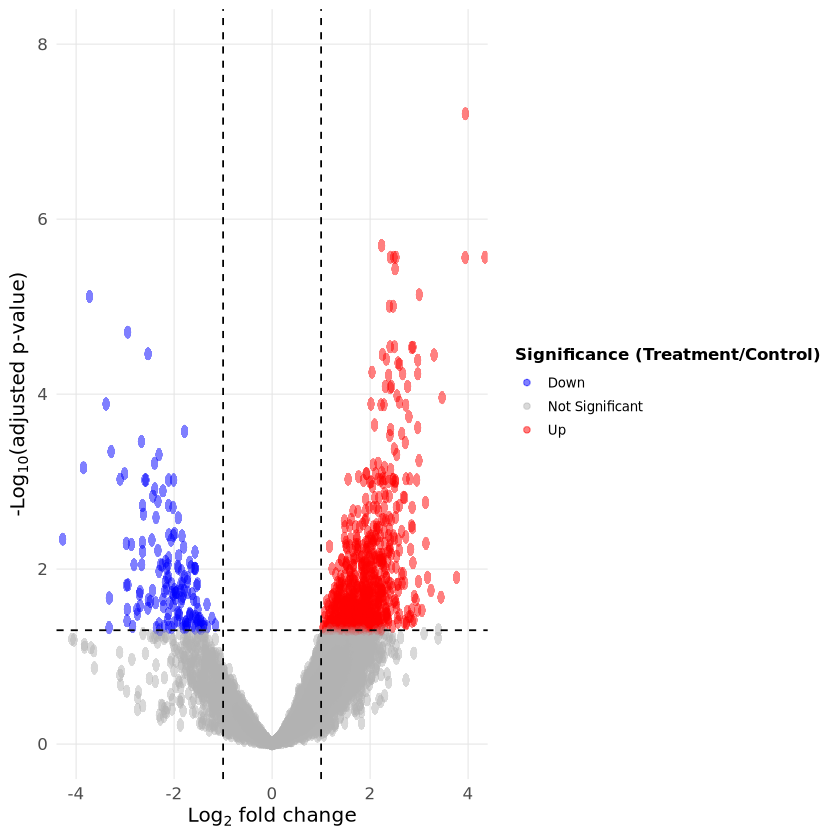

In [4]:
Volcano = volcano_plot(DMSO_R, ymax = 8, xlims = c(-4,4))
ggsave("volcano_plots/NONO_DMSO_R_Volcano.svg", plot = Volcano, width = 6, height = 4, dpi = 300)
Volcano

Warning message:
“Removed 4018 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”
Warning message:
“Removed 4018 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”


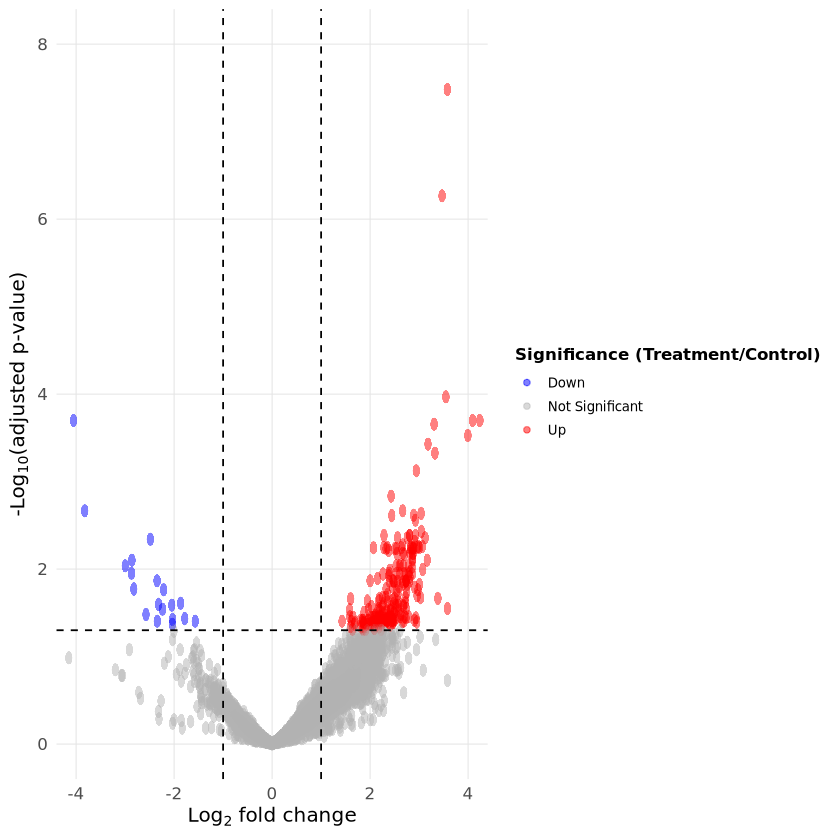

In [5]:
Volcano = volcano_plot(S_R, ymax = 8, xlims = c(-4,4))
ggsave("volcano_plots/NONO_S_R_Volcano.svg", plot = Volcano, width = 6, height = 4, dpi = 300)
Volcano

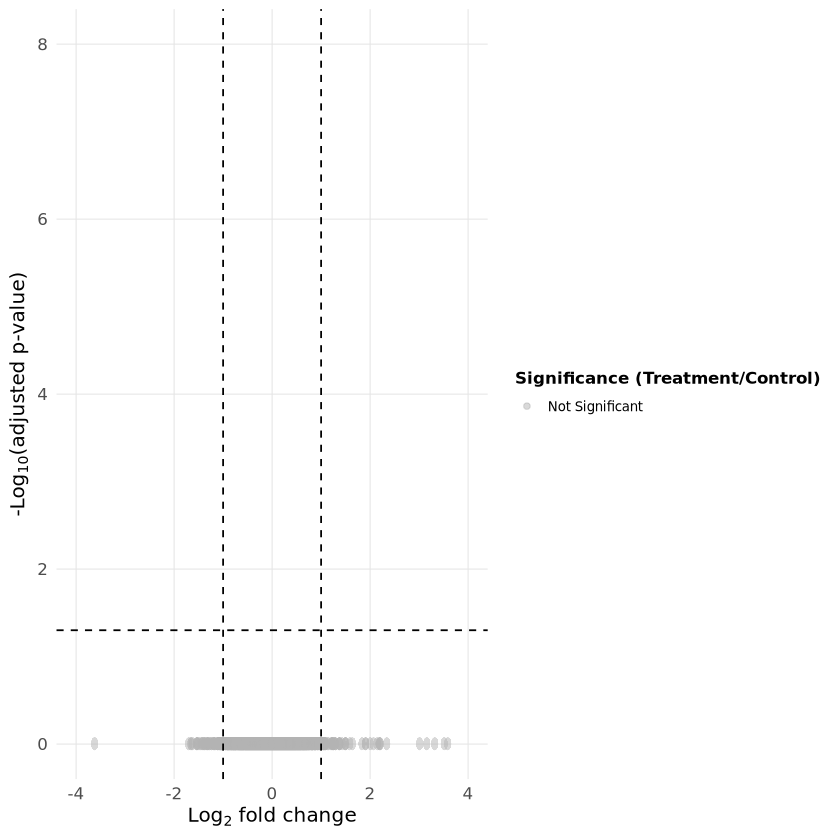

In [6]:
Volcano = volcano_plot(DMSO_S, ymax = 8, xlims = c(-4,4))
ggsave("volcano_plots/NONO_DMSO_S_Volcano.svg", plot = Volcano, width = 6, height = 4, dpi = 300)
Volcano

# DDX42 volcanoes

In [7]:
DMSO_active = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_active/tables/all_windows.tsv",
                  sep = "\t")
S_active = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_inactive_active/tables/all_windows.tsv",
                  sep = "\t")
DMSO_inactive = read.csv("~/scratch/ch_diffbind/testing/output/MOR_test/DDX42_DMSO_inactive/tables/all_windows.tsv",
                  sep = "\t")

Warning message:
“Removed 4962 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”
Warning message:
“Removed 4962 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”


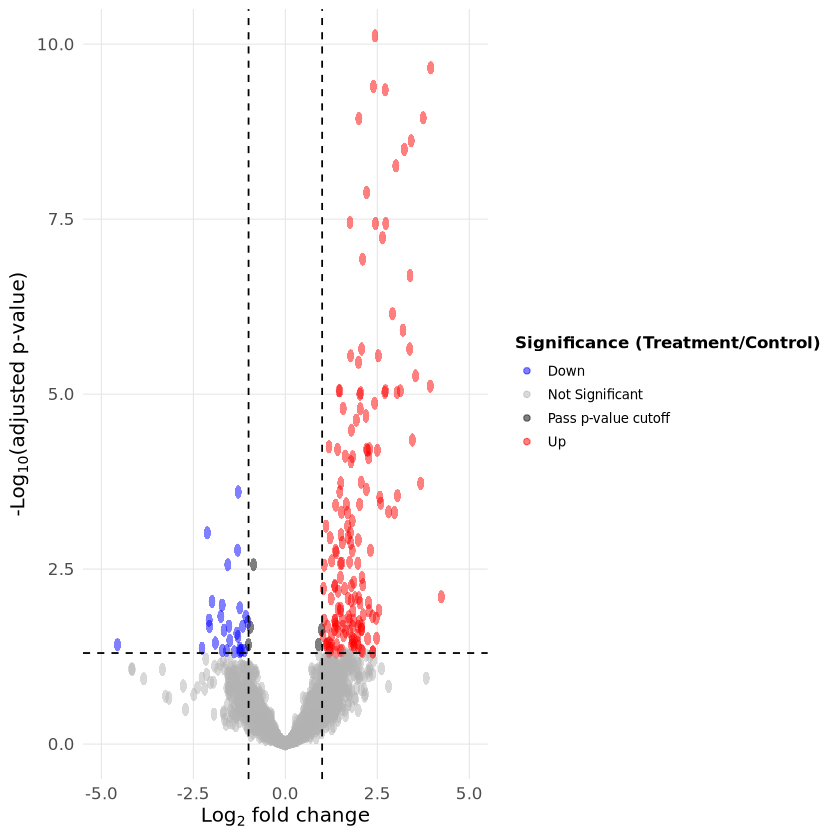

In [8]:
Volcano = volcano_plot(DMSO_active, ymax = 10, xlims = c(-5,5))
ggsave("volcano_plots/DDX42_DMSO_active_Volcano.svg", plot = Volcano, width = 6, height = 4, dpi = 300)
Volcano

Warning message:
“Removed 5059 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”
Warning message:
“Removed 5059 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”


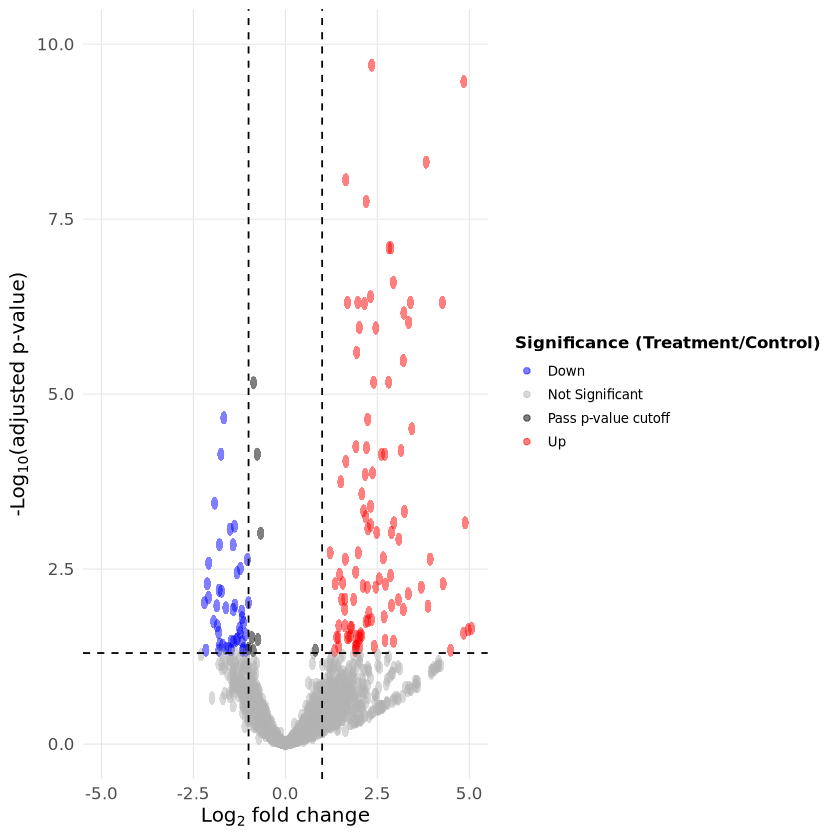

In [9]:
Volcano = volcano_plot(S_active, ymax = 10, xlims = c(-5,5))
ggsave("volcano_plots/DDX42_inactive_active_Volcano.svg", plot = Volcano, width = 6, height = 4, dpi = 300)
Volcano

Warning message:
“Removed 4546 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”
Warning message:
“Removed 4546 rows containing missing values or values outside the scale range
(`geom_scattermore()`).”


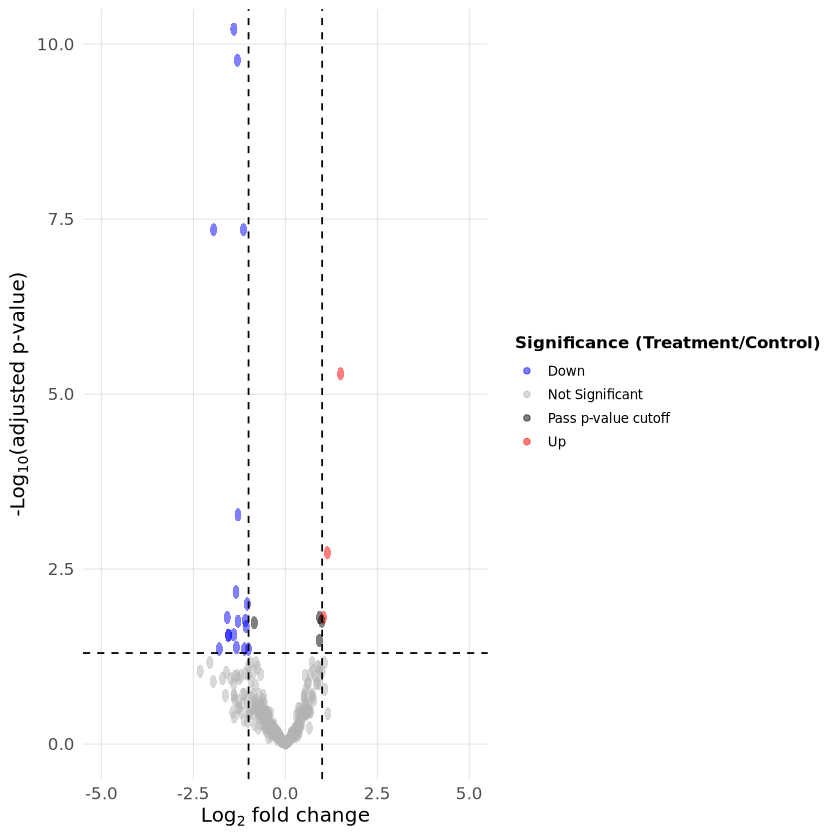

In [10]:
Volcano = volcano_plot(DMSO_inactive, ymax = 10, xlims = c(-5,5))
ggsave("volcano_plots/DDX42_DMSO_inactive_Volcano.svg", plot = Volcano, width = 6, height = 4, dpi = 300)
Volcano